# Nesso-1 on Runs N' Poses: does structural familiarity matter?

## Headline result

We evaluated Nesso-1 on **100 frozen protein--ligand systems** spanning low to
high similarity to structures available before Nesso's September 2021
structural-training cutoff.

The result is clear: Nesso's predicted protein--ligand distance representation
is substantially more accurate for familiar systems. Its own entropy is also a
useful warning signal when that representation is inaccurate.

> This is a **structural-representation benchmark**, not an affinity benchmark.
> Runs N' Poses does not provide systematic experimental affinity labels.


## 1. What did we do?

The evaluation was deliberately separated into an inference stage and a
scoring stage:

1. We froze 100 diverse complexes before inspecting any Nesso prediction.
   Each familiarity bin contains 12--13 systems, and PDB entries, structural
   clusters, and canonical ligand chemistries are unique.
2. Nesso received only the deposited **protein sequence** and **ligand SMILES**.
3. Nesso produced an affinity output, a protein--ligand **distogram**, and
   distogram entropy. Experimental coordinates were not model inputs.
4. Only after inference, we mapped Nesso's protein and ligand tokens to the
   experimental complex and scored the predicted distance distributions,
   contacts, and binding pocket.

```text
sequence + SMILES  -->  Nesso-1  -->  distogram + entropy
                                             |
experimental complex  -----------------------+--> structural metrics
```

All **100/100 inference runs** and **100/100 final scoring records** completed.


In [1]:
from pathlib import Path
import json
import warnings

warnings.filterwarnings("ignore", category=UserWarning)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display


def find_repository_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / "reports").is_dir() and (candidate / "configs").is_dir():
            return candidate
    raise FileNotFoundError("Open this notebook from inside BindingAffinityPredictor")


REPO = find_repository_root(Path.cwd())
RESULTS = REPO / "reports/exp012_nesso1_rnp_distogram_generalization/results"
summary = json.loads((RESULTS / "summary.json").read_text())
systems = pd.read_csv(RESULTS / "per_system_metrics.csv")

assert len(systems) == 100
assert systems["sample_id"].nunique() == 100
assert summary["aggregate"]["systems_failed"] == 0

{
    "repository": str(REPO),
    "systems": len(systems),
    "inference_status": summary["run"]["status"],
    "final_scoring_failures": summary["aggregate"]["systems_failed"],
}


{'repository': '/mnt/hdd2/BindingAffinityPredictor',
 'systems': 100,
 'inference_status': 'complete',
 'final_scoring_failures': 0}

## 2. What does Nesso predict structurally?

Nesso does not write an all-atom 3D complex. It predicts a categorical
distribution over distances for every protein-token/ligand-atom pair:

$$
p_{ij}(b) = P\!\left(d_{ij}\text{ lies in distance bin }b\right).
$$

There are 64 distance bins. A standard protein residue is represented by its
$C_\beta$ position ($C_\alpha$ for glycine), and every ligand heavy atom is a
separate token. The expected distance is

$$
\mathbb{E}[d_{ij}] = \sum_b p_{ij}(b)c_b,
$$

where $c_b$ is the representative distance of bin $b$.

With pocket refinement enabled, the saved map contains refined predictions in
Nesso's selected crop and its initial global predictions elsewhere. We score
all experimentally resolved interface pairs, including a true pocket that
Nesso failed to place inside its crop.


## 3. What do the metrics mean?

### Distogram negative log likelihood (NLL)

For the experimentally observed distance bin $b^*_{ij}$,

$$
\mathrm{NLL}_{ij}=-\log p_{ij}(b^*_{ij}).
$$

We average this over true protein--ligand interface pairs within 15 Å.
**Lower is better.** A uniform distribution over 64 bins gives
$\log(64)\approx4.16$. NLL above 4.16 means the correct distance received less
probability than a uniform guess; a confidently incorrect prediction can be
much worse than 4.16.

### Expected-distance MAE

Absolute error between the expected and experimental token distances, in Å.
**Lower is better.**

### Contact AP and AUROC

These ask whether true 6 Å token contacts rank above noncontacts. **Higher is
better.** AUROC measures relative ordering; AP is more sensitive to the small
fraction of true contacts.

### Physical-pocket F1

A true pocket residue has any protein heavy atom within 6 Å of the ligand.
F1 balances pocket precision and recall. **Higher is better.**

### Spearman $\rho$

Spearman correlation compares ranks rather than assuming a linear relation.
$\rho=+1$ is perfectly increasing, $\rho=-1$ perfectly decreasing, and
$\rho\approx0$ means no consistent monotonic trend. Because NLL and MAE are
errors, better performance with familiarity gives negative $\rho$. For AP,
AUROC, and F1, better performance gives positive $\rho$.


## 4. How do unfamiliar and familiar systems differ?


In [2]:
aggregate = summary["aggregate"]
bin_order = ["0-20", "20-30", "30-40", "40-50", "50-60", "60-70", "70-80", "80-100"]

columns = {
    "Familiarity bin": [],
    "N": [],
    "Distogram NLL ↓": [],
    "Distance MAE (Å) ↓": [],
    "Contact AP ↑": [],
    "Contact AUROC ↑": [],
    "Pocket F1 ↑": [],
}
metric_columns = {
    "Distogram NLL ↓": "interface_distogram_nll",
    "Distance MAE (Å) ↓": "interface_expected_distance_mae_angstrom",
    "Contact AP ↑": "token_contact_average_precision_at_6a",
    "Contact AUROC ↑": "token_contact_auroc_at_6a",
    "Pocket F1 ↑": "physical_pocket_f1_at_6a",
}

for bin_name in bin_order:
    result = aggregate["by_familiarity_bin"][bin_name]
    columns["Familiarity bin"].append(bin_name)
    columns["N"].append(result["n"])
    for label, metric in metric_columns.items():
        columns[label].append(result["metrics"][metric]["median"])

bin_table = pd.DataFrame(columns).set_index("Familiarity bin")
display(bin_table.style.format({column: "{:.3f}" for column in metric_columns}))


,N,Distogram NLL ↓,Distance MAE (Å) ↓,Contact AP ↑,Contact AUROC ↑,Pocket F1 ↑
Familiarity bin,,,,,,
0-20,13,6.009,6.963,0.048,0.829,0.000
20-30,13,4.126,3.067,0.229,0.973,0.235
30-40,13,4.019,2.316,0.220,0.972,0.356
40-50,13,3.645,1.876,0.412,0.989,0.421
50-60,12,2.514,0.697,0.911,0.998,0.710
60-70,12,1.892,0.491,0.932,0.999,0.700
70-80,12,1.546,0.370,0.968,1.000,0.717
80-100,12,1.854,0.441,0.952,0.999,0.648


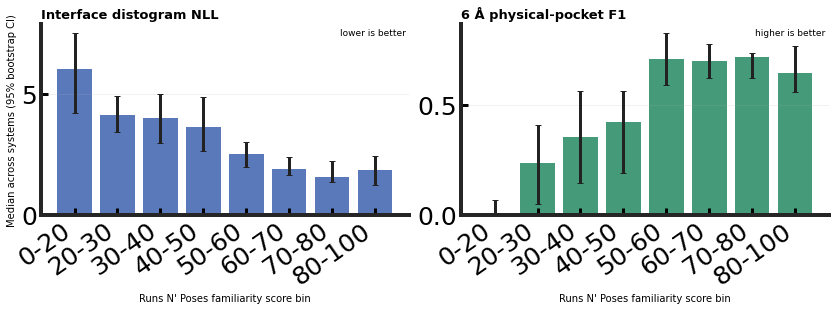

In [3]:
plt.rcParams.update({
    "text.usetex": False,
    "font.family": "DejaVu Sans",
    "font.size": 10,
    "axes.titlesize": 13,
    "axes.labelsize": 10,
})


def bin_values(metric):
    medians, lower, upper = [], [], []
    for bin_name in bin_order:
        result = aggregate["by_familiarity_bin"][bin_name]["metrics"][metric]
        medians.append(result["median"])
        lower.append(result["lower_95"])
        upper.append(result["upper_95"])
    medians = np.asarray(medians)
    return medians, medians - np.asarray(lower), np.asarray(upper) - medians


fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2), constrained_layout=True)
x = np.arange(len(bin_order))
panels = [
    ("interface_distogram_nll", "Interface distogram NLL", "lower is better", "#4267B2"),
    ("physical_pocket_f1_at_6a", "6 Å physical-pocket F1", "higher is better", "#2B8C68"),
]
for ax, (metric, title, direction, color) in zip(axes, panels):
    values, low, high = bin_values(metric)
    ax.bar(x, values, color=color, alpha=0.88)
    ax.errorbar(x, values, yerr=np.vstack([low, high]), fmt="none", color="#222222", capsize=3)
    ax.set_title(title, loc="left", weight="bold")
    ax.text(0.99, 0.98, direction, transform=ax.transAxes, ha="right", va="top", fontsize=9)
    ax.set_xticks(x, bin_order, rotation=35, ha="right")
    ax.set_xlabel("Runs N' Poses familiarity score bin")
    ax.grid(axis="y", alpha=0.22)
    ax.spines[["top", "right"]].set_visible(False)
axes[0].set_ylabel("Median across systems (95% bootstrap CI)")
plt.show()


### Reading this result

- In the **0--20 unfamiliar group**, median distance error is 6.96 Å and
  median pocket F1 is zero. A median of zero does not mean every complex fails;
  it means at least half have no useful 6 Å pocket overlap at this threshold.
- Performance improves gradually through the 20--50 bins.
- Between **50 and 60 familiarity**, contact AP jumps above 0.9 and median
  distance error falls below 1 Å.
- The **70--80 familiar group** has median distance error 0.37 Å and pocket F1
  0.72.
- The 80--100 group is slightly worse than 70--80 on some metrics. With only
  12--13 examples per bin, we should interpret the continuous trend and its
  uncertainty rather than demand perfectly monotonic bars.

The unfamiliar group's median NLL of 6.01 is worse than the uniform reference
of 4.16. Thus Nesso is often not merely uncertain: it can assign confidently
low probability to the experimentally correct arrangement.


In [4]:
rho_results = aggregate["spearman_vs_familiarity"]
rho_rows = []
for label, metric in metric_columns.items():
    result = rho_results[metric]
    rho_rows.append({
        "Metric": label,
        "Spearman rho": result["rho"],
        "95% CI lower": result["lower_95"],
        "95% CI upper": result["upper_95"],
    })

rho_table = pd.DataFrame(rho_rows).set_index("Metric")
display(rho_table.style.format("{:+.3f}"))


,Spearman rho,95% CI lower,95% CI upper
Metric,,,
Distogram NLL ↓,-0.704,-0.796,-0.577
Distance MAE (Å) ↓,-0.709,-0.814,-0.584
Contact AP ↑,+0.682,+0.543,+0.787
Contact AUROC ↑,+0.662,+0.519,+0.764
Pocket F1 ↑,+0.647,+0.503,+0.760


The signs are exactly what better performance with familiarity predicts:

- NLL and MAE have $\rho\approx-0.70$: more familiar systems tend to have
  smaller errors.
- Contact AP and pocket F1 have $\rho\approx+0.65$ to $+0.68$: more familiar
  systems tend to recover contacts and pockets better.
- Every bootstrap interval remains far from zero, supporting a strong
  monotonic association in this selected panel.

This is an association, not proof that Nesso literally memorized individual
training examples. Familiarity may covary with pocket flexibility, unusual
chemistry, structure quality, or other sources of intrinsic difficulty.


## 5. Can Nesso tell us when it is wrong?


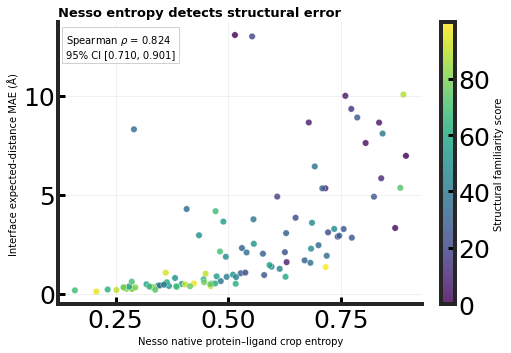

In [5]:
entropy = systems["entropy_crop_pl"]
distance_error = systems["interface_expected_distance_mae_angstrom"]
familiarity = systems["familiarity_score_0_to_100"]
entropy_result = aggregate["entropy_error_spearman"]["interface_expected_distance_mae_angstrom"]

fig, ax = plt.subplots(figsize=(7.0, 4.8), constrained_layout=True)
points = ax.scatter(
    entropy,
    distance_error,
    c=familiarity,
    cmap="viridis",
    s=42,
    alpha=0.82,
    edgecolor="white",
    linewidth=0.4,
)
ax.set_title("Nesso entropy detects structural error", loc="left", weight="bold")
ax.set_xlabel("Nesso native protein–ligand crop entropy")
ax.set_ylabel("Interface expected-distance MAE (Å)")
ax.text(
    0.02,
    0.96,
    f"Spearman $\\rho$ = {entropy_result['rho']:.3f}\n"
    f"95% CI [{entropy_result['lower_95']:.3f}, {entropy_result['upper_95']:.3f}]",
    transform=ax.transAxes,
    va="top",
    bbox={"facecolor": "white", "edgecolor": "#cccccc", "alpha": 0.9},
)
ax.grid(alpha=0.22)
ax.spines[["top", "right"]].set_visible(False)
colorbar = fig.colorbar(points, ax=ax)
colorbar.set_label("Structural familiarity score")
plt.show()


In [6]:
partial = aggregate["exploratory_entropy_error_partial_spearman"][
    "interface_expected_distance_mae_angstrom"
]
entropy_rows = [
    {
        "Analysis": "Raw entropy vs MAE",
        **aggregate["entropy_error_spearman"]["interface_expected_distance_mae_angstrom"],
    },
    {
        "Analysis": "Partial: control familiarity",
        **partial["controlling_familiarity"],
    },
    {
        "Analysis": "Partial: control familiarity + protein/ligand size",
        **partial["controlling_familiarity_protein_and_ligand_size"],
    },
]
entropy_table = pd.DataFrame(entropy_rows).set_index("Analysis")[["rho", "lower_95", "upper_95"]]
display(entropy_table.style.format("{:+.3f}"))


,rho,lower_95,upper_95
Analysis,,,
Raw entropy vs MAE,+0.824,+0.710,+0.901
Partial: control familiarity,+0.671,+0.447,+0.826
Partial: control familiarity + protein/ligand size,+0.645,+0.412,+0.807


Higher entropy means Nesso spreads probability across more distance bins. Its
strong positive correlation with error means uncertainty is informative.

The exploratory partial correlations ask whether entropy is only acting as a
proxy for familiarity. It is not: the entropy--error relationship remains
strong after controlling familiarity ($\rho_{partial}=0.671$), and after also
controlling protein length and ligand size ($\rho_{partial}=0.645$).

These partial analyses were added after the primary familiarity analysis and
should therefore be treated as exploratory evidence to confirm on a new panel.


## 6. Scientific conclusion and next experiment

### What this experiment supports

1. Nesso-1's structural representation is much less reliable for unfamiliar
   protein-pocket/ligand-pose configurations.
2. The model's native entropy is a promising reliability indicator and carries
   information beyond the benchmark familiarity score alone.

### What it does not establish

- It does not prove literal memorization of individual structures.
- It does not test affinity accuracy: the benchmark lacks systematic affinity
  labels.
- It does not compare Nesso against a coordinate-generating model on the same
  panel.
- The diversity-stratified 100 systems are not a random sample of the PDB.

### Recommended next step

Run a coordinate-generating model, such as Boltz-2, on this identical frozen
panel. Then ask whether ligand-pose and pocket accuracy show the same
familiarity dependence and whether each model's confidence identifies its own
failures. We should also model performance jointly against familiarity,
protein length, ligand size, and experimental structure quality.

## Reproducibility links

- Experiment definition: `experiments/exp012_nesso1_rnp_distogram_generalization/`
- Metric decision: `docs/decisions/0002-nesso-rnp-coordinate-free-structural-metrics.md`
- Scoring code: `scripts/analyze_nesso_rnp_distograms.py`
- Compact result: `reports/exp012_nesso1_rnp_distogram_generalization/`
- Raw predictions remain under ignored `runs/` and are not committed.
